# Bylaw Violation Classification
## Exploratory Data Analysis & Baseline Model

**Research Question:** Can machine learning techniques be used to classify and predict bylaw violations in residential communities, enabling proactive enforcement and more efficient compliance management?

**Dataset:** Austin Code Complaint Cases — [City of Austin Open Data Portal](https://data.austintexas.gov/Public-Safety/Austin-Code-Complaint-Cases/6wtj-zbtb)  
**Target Variable:** `violation_upheld` — whether a complaint results in a confirmed violation (1) or no violation found (0)  
**Notebook:** `notebooks/eda.ipynb`

## 0. Setup — Imports

In [1]:
import os
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

## 1. Data Acquisition

Data is sourced from the City of Austin Open Data Portal. It contains code enforcement complaint cases filed with Austin Code Enforcement, including complaint type, resolution status, dates, location, and inspector information. The dataset is downloaded once and cached locally.

In [2]:
os.makedirs('../data', exist_ok=True)

DATA_PATH = '../data/austin_code_complaints.csv'
URL = 'https://data.austintexas.gov/api/views/6wtj-zbtb/rows.csv?accessType=DOWNLOAD'

if not os.path.exists(DATA_PATH):
    print('Downloading dataset (~83k rows, may take a moment)...')
    urllib.request.urlretrieve(URL, DATA_PATH)
    print(f'Saved to {DATA_PATH}')
else:
    print(f'Data already cached at {DATA_PATH}')

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = df.columns.str.lower()  # full CSV export uses uppercase headers
print(f'Shape: {df.shape}')
df.head(3)

Data already cached at ../data/austin_code_complaints.csv
Shape: (82984, 27)


,case_id,priority,status,address_long,house_number,street_name,city,state,zip_code,opened_date,closed_date,department,case_type,description,inspector,date_updated,last_update,violationcasenumber,violationcaselink,parcelid,location,latitude,longitude,repeatoffenderrelated,shorttermrentalrelated,servicerequestnumber,reportedby
0,2025-005905 CC,5.0,Closed,1100 BLAIR WAY,1100,BLAIR WAY,AUSTIN,TX,78704.0,01/16/2025,01/16/2025,Code Enforcement,Complaints,Land Use Violation(s),Roman Lopez|(512) 415-8397,01/16/2025 12:00:00 AM,Inspection Performed/Abated by Inspector,NaN,NaN,0405061501,"(30.23689875, -97.77211841)",30.236899,-97.772118,No,NaN,NaN,COA Department
1,2023-151300 CC,5.0,Closed,1107 CUMBERLAND ROAD,1107,CUMBERLAND RD,AUSTIN,TX,78704.0,11/23/2023,11/27/2023,Code Enforcement,Complaints,Property Abatement,Monroe Yarbrough|512-788-3046,11/27/2023 12:00:00 AM,No Violation(s) Found/Inspection Performed,NaN,NaN,0403050539,"(30.24099532, -97.76957386)",30.240995,-97.769574,No,NaN,23-00522848,Anonymous
2,2023-129349 CC,5.0,Closed,6709 WENTWORTH DRIVE,6709,WENTWORTH DR,AUSTIN,TX,78724.0,10/05/2023,10/11/2023,Code Enforcement,Complaints,Property Abatement,Aaron Janke|(512) 945-8356,10/11/2023 12:00:00 AM,Inspection Performed/Abated by Community Court,NaN,NaN,0217380301,"(30.2938479, -97.63073535)",30.293848,-97.630735,No,NaN,23-00459390,Complainant


## 2. Initial Exploration

In [3]:
# Column names, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82984 entries, 0 to 82983
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   case_id                 82984 non-null  str    
 1   priority                80433 non-null  float64
 2   status                  82984 non-null  str    
 3   address_long            82932 non-null  str    
 4   house_number            72999 non-null  str    
 5   street_name             73005 non-null  str    
 6   city                    72999 non-null  str    
 7   state                   73001 non-null  str    
 8   zip_code                72628 non-null  float64
 9   opened_date             82984 non-null  str    
 10  closed_date             79599 non-null  str    
 11  department              82984 non-null  str    
 12  case_type               82984 non-null  str    
 13  description             82984 non-null  str    
 14  inspector               82984 non-null  str    
 

In [4]:
# Summary statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,82984,82984,2025-005905 CC,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,80433.0,NaN,NaN,NaN,4.014211,1.354117,0.0,2.0,5.0,5.0,90.0
status,82984,3,Closed,79601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address_long,82932,47403,4807 PROCK LANE,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_number,72999,5499,1700,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,73005,5714,N LAMAR BLVD,992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,72999,14,AUSTIN,72965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,73001,1,TX,73001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,72628.0,NaN,NaN,NaN,78733.535978,22.576575,78610.0,78721.0,78741.0,78752.0,78759.0
opened_date,82984,1282,04/22/2025,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Steps:
1. Identify and visualize missing values
2. Remove duplicate records
3. Parse date columns
4. Standardize text and categorical fields

In [5]:
# Missing value summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing[missing.missing_count > 0]

,missing_count,missing_pct
shorttermrentalrelated,79585,95.90
violationcaselink,62753,75.62
violationcasenumber,59348,71.52
parcelid,10856,13.08
zip_code,10356,12.48
latitude,10309,12.42
location,10309,12.42
longitude,10309,12.42
house_number,9985,12.03
street_name,9979,12.03


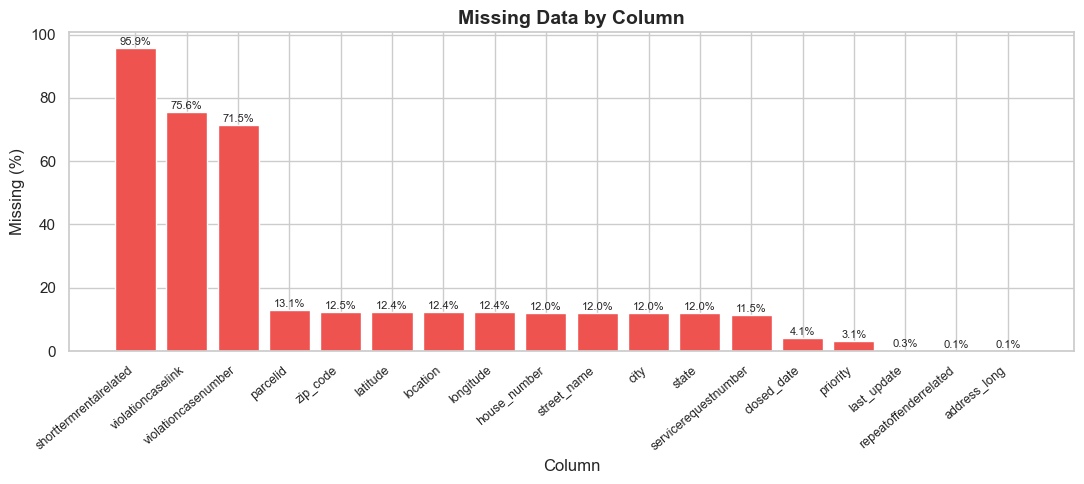

In [6]:
# Visualize missingness by column
miss_plot = missing[missing.missing_pct > 0]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(miss_plot.index, miss_plot['missing_pct'],
              color='#EF5350', edgecolor='white', linewidth=1)
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
ax.set_xticklabels(miss_plot.index, rotation=40, ha='right', fontsize=9)

for bar, val in zip(bars, miss_plot['missing_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Remove duplicate rows
print(f'Duplicate rows before: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after dedup: {df.shape}')

Duplicate rows before: 0
Shape after dedup: (82984, 27)


In [8]:
# Parse dates
for col in ['opened_date', 'closed_date', 'date_updated']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Fill missing categoricals with sensible defaults
df['repeatoffenderrelated'] = df['repeatoffenderrelated'].fillna('No')
df['shorttermrentalrelated'] = df['shorttermrentalrelated'].fillna('No')
df['description'] = df['description'].fillna('Unknown')
df['reportedby'] = df['reportedby'].fillna('Unknown')

# Normalize zip code to 5-digit string
df['zip_code'] = df['zip_code'].astype(str).str.strip().str.split('.').str[0]

print('Cleaning complete.')
df[['opened_date', 'closed_date', 'description', 'status', 'last_update']].head(5)

Cleaning complete.


,opened_date,closed_date,description,status,last_update
0,2025-01-16,2025-01-16,Land Use Violation(s),Closed,Inspection Performed/Abated by Inspector
1,2023-11-23,2023-11-27,Property Abatement,Closed,No Violation(s) Found/Inspection Performed
2,2023-10-05,2023-10-11,Property Abatement,Closed,Inspection Performed/Abated by Community Court
3,2026-02-20,2026-02-20,Land Use Violation(s),Closed,Closed/Duplicate Case
4,2025-11-15,2025-11-18,Structure Condition Violation(s),Closed,Supervisor Review


## 4. Target Variable Engineering

The `last_update` column records how a case was resolved. We derive a binary classification target:

| `violation_upheld` | `last_update` values | Meaning |
|---|---|---|
| `1` | Abated, Voluntary Compliance, Legal Action, Abatement | A violation was confirmed and corrected |
| `0` | No Violation(s) Found | Inspection found no violation |
| excluded | Duplicate, Referred, Cancelled, Follow-up, etc. | Administrative — no substantive outcome |

"Voluntary Compliance" is classified as 1 because it indicates an inspector found an issue that the property owner then corrected — confirming a real violation existed.

In [9]:
# Inspect all unique resolution outcomes
print(df['last_update'].value_counts(dropna=False).head(25).to_string())

last_update
No Violation(s) Found/Inspection Performed        33532
Closed due to Voluntary Compliance                16862
Closed/Duplicate Case                             11475
Inspection Performed/Abated by Inspector           4878
Referred to Appropriate Agency                     4266
Closed due to Abatement                            2134
Follow-up Inspection                               1771
Inspection Performed/Abated by Community Court     1303
Cancelled                                          1002
Legal Action-All Deficiencies Satisfied             990
Inspection Performed/ Voluntary Compliance          946
Contact Performed                                   875
Inspection Performed                                499
Send CV Notice                                      499
Information Update                                  483
Supervisor Review                                   310
NaN                                                 231
Code Connect Contact                

In [10]:
def encode_outcome(text):
    """Map resolution text to binary label. Returns NaN for administrative closures."""
    if pd.isna(text):
        return np.nan
    t = text.lower()
    if 'no violation' in t:
        return 0
    # Voluntary compliance = inspector found an issue; owner corrected it without citation
    # Abatement, legal action, and direct enforcement are all confirmed violations
    if any(kw in t for kw in ['abated', 'abatement', 'voluntary compliance',
                               'citation issued', 'legal action']):
        return 1
    return np.nan

# Apply only to closed cases with known outcomes
df['violation_upheld'] = df['last_update'].apply(encode_outcome)

counts = df['violation_upheld'].value_counts(dropna=False)
print(counts)
print(f'\nRows with a defined target: {df["violation_upheld"].notna().sum():,}')
print(f'Rows excluded (admin closures / open): {df["violation_upheld"].isna().sum():,}')

violation_upheld
0.0    33558
1.0    27114
NaN    22312
Name: count, dtype: int64

Rows with a defined target: 60,672
Rows excluded (admin closures / open): 22,312


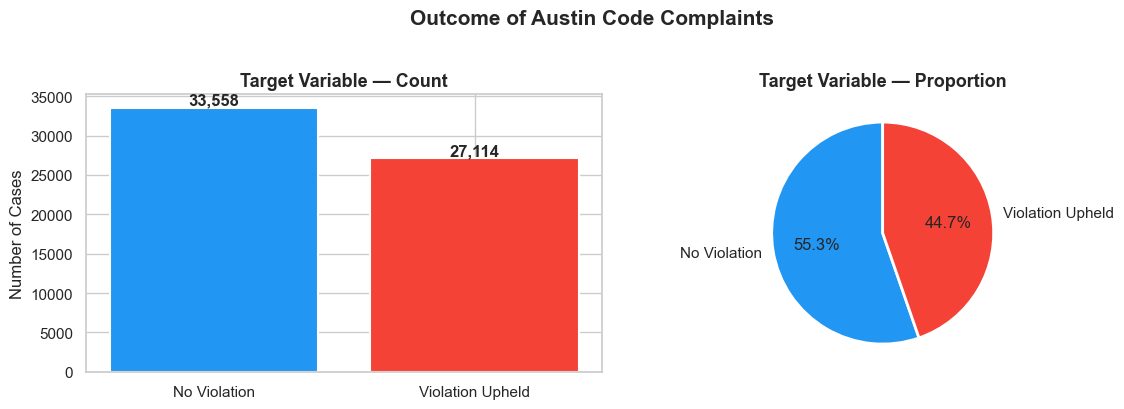

In [11]:
target_data = df['violation_upheld'].dropna()
labels = {0.0: 'No Violation', 1.0: 'Violation Upheld'}
counts = target_data.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    [labels[i] for i in counts.index], counts.values,
    color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5
)
axes[0].set_title('Target Variable — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Cases')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=[labels[i] for i in counts.index],
    autopct='%1.1f%%',
    colors=['#2196F3', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Target Variable — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Outcome of Austin Code Complaints', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

We extract and transform variables from the raw data for use in modeling:

| Feature | Source | Description |
|---|---|---|
| `days_to_close` | `closed_date - opened_date` | Enforcement response time |
| `opened_month` | `opened_date` | Filing month (1–12) |
| `opened_dayofweek` | `opened_date` | Filing day of week (0=Mon) |
| `opened_year` | `opened_date` | Filing year |
| `is_repeat_offender` | `repeatoffenderrelated` | 1 if flagged repeat offender |
| `is_short_term_rental` | `shorttermrentalrelated` | 1 if short-term rental involved |

In [12]:
# Build modeling dataset from closed cases with a defined outcome
df_model = df[df['violation_upheld'].notna()].copy()

# Temporal features
df_model['opened_month'] = df_model['opened_date'].dt.month
df_model['opened_dayofweek'] = df_model['opened_date'].dt.dayofweek
df_model['opened_year'] = df_model['opened_date'].dt.year

# Days to resolve the complaint
df_model['days_to_close'] = (
    df_model['closed_date'] - df_model['opened_date']
).dt.days

# Boolean flags → integer
df_model['is_repeat_offender'] = (df_model['repeatoffenderrelated'] == 'Yes').astype(int)
df_model['is_short_term_rental'] = (df_model['shorttermrentalrelated'] == 'Yes').astype(int)

# Priority as numeric
df_model['priority'] = pd.to_numeric(df_model['priority'], errors='coerce')

print(f'Modeling dataset shape: {df_model.shape}')
df_model[['priority', 'days_to_close', 'opened_month', 'opened_dayofweek',
          'is_repeat_offender', 'is_short_term_rental', 'violation_upheld']].head()

Modeling dataset shape: (60672, 34)


,priority,days_to_close,opened_month,opened_dayofweek,is_repeat_offender,is_short_term_rental,violation_upheld
0,5.0,0.0,1,3,0,0,1.0
1,5.0,4.0,11,3,0,0,0.0
2,5.0,6.0,10,3,0,0,1.0
5,5.0,4.0,3,3,0,0,1.0
7,5.0,0.0,4,1,0,0,0.0


## 6. Exploratory Data Analysis
### 6.1 Univariate Analysis

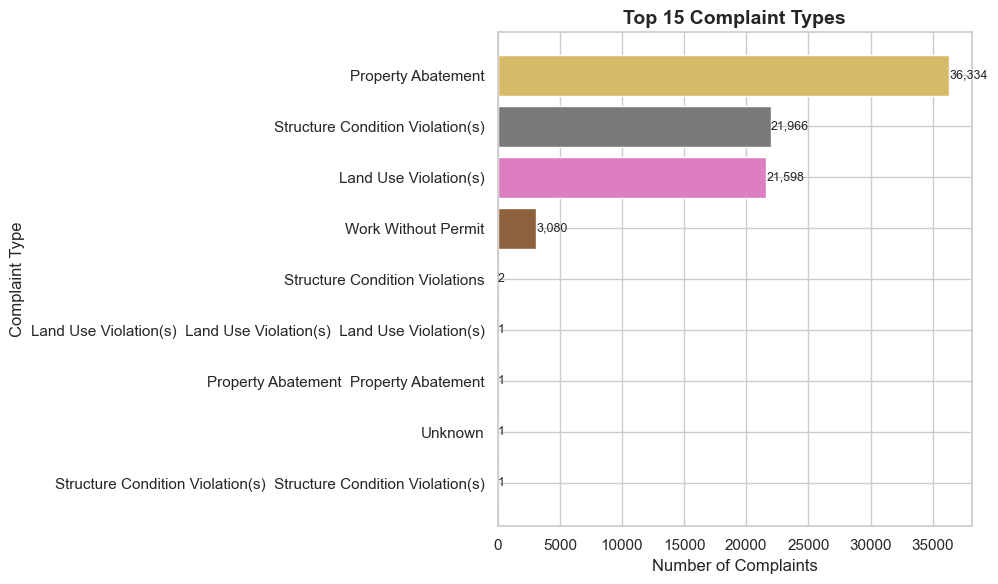

In [13]:
# Top 15 complaint types
top_types = df['description'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_types.index[::-1], top_types.values[::-1],
    color=sns.color_palette('muted', 15)
)
ax.set_title('Top 15 Complaint Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('Complaint Type')
for bar, val in zip(bars, top_types.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

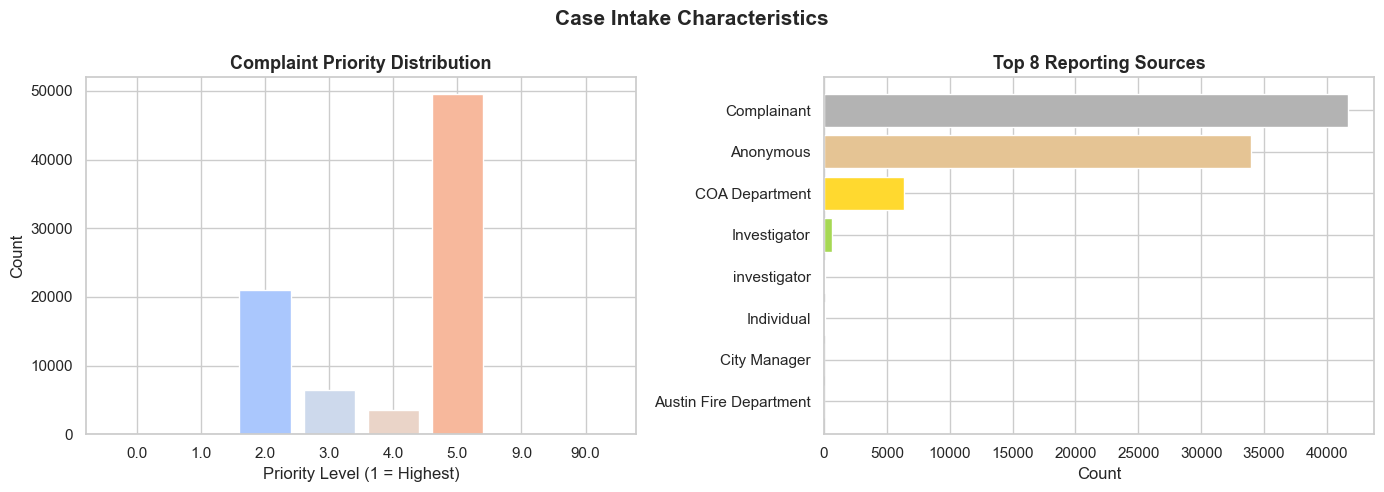

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority distribution
priority_counts = df['priority'].value_counts().sort_index()
axes[0].bar(
    priority_counts.index.astype(str), priority_counts.values,
    color=sns.color_palette('coolwarm', len(priority_counts))
)
axes[0].set_title('Complaint Priority Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Priority Level (1 = Highest)')
axes[0].set_ylabel('Count')

# Reporting source
reported = df['reportedby'].value_counts().head(8)
axes[1].barh(
    reported.index[::-1], reported.values[::-1],
    color=sns.color_palette('Set2', 8)
)
axes[1].set_title('Top 8 Reporting Sources', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Case Intake Characteristics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

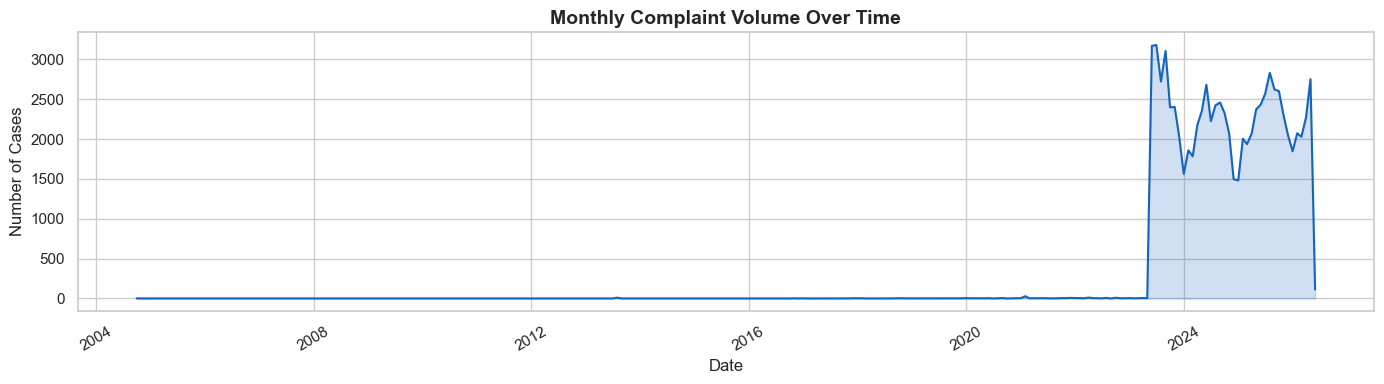

In [15]:
# Monthly complaint volume over time
monthly = (
    df.set_index('opened_date')
      .resample('ME')
      .size()
      .rename('cases')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, linewidth=1.5, color='#1565C0')
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='#1565C0')
ax.set_title('Monthly Complaint Volume Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Cases')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

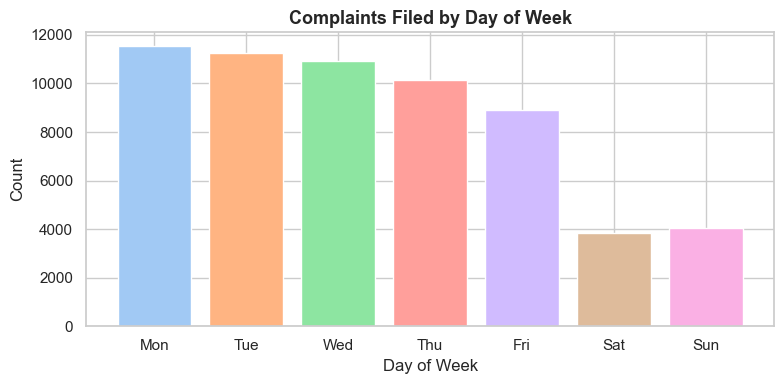

In [16]:
# Cases by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df_model['opened_dayofweek'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [day_names[i] for i in dow_counts.index],
    dow_counts.values,
    color=sns.color_palette('pastel', 7)
)
ax.set_title('Complaints Filed by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 6.2 Bivariate Analysis — Outcome vs Features

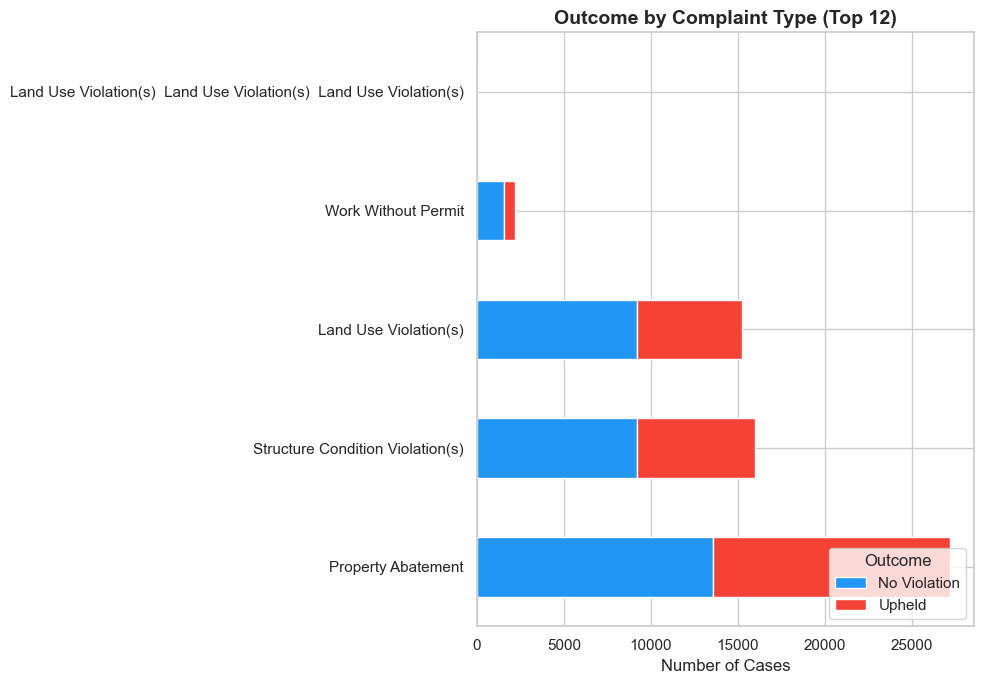

In [17]:
# Stacked bar: outcome by complaint type (top 12)
type_outcome = (
    df_model
    .groupby(['description', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
type_outcome.columns = ['No Violation', 'Upheld']
type_outcome['total'] = type_outcome.sum(axis=1)
top12 = type_outcome.nlargest(12, 'total')

fig, ax = plt.subplots(figsize=(10, 7))
top12[['No Violation', 'Upheld']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2196F3', '#F44336']
)
ax.set_title('Outcome by Complaint Type (Top 12)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cases')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

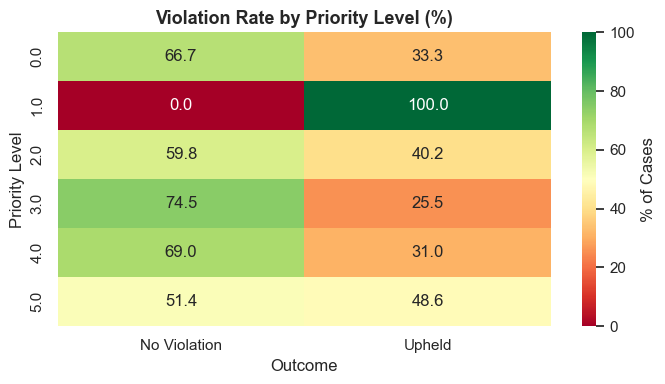

In [18]:
# Heatmap: violation rate by priority level
priority_outcome = (
    df_model
    .groupby(['priority', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
priority_outcome.columns = ['No Violation', 'Upheld']
rate_pct = priority_outcome.div(priority_outcome.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    rate_pct, annot=True, fmt='.1f', cmap='RdYlGn',
    cbar_kws={'label': '% of Cases'}, ax=ax
)
ax.set_title('Violation Rate by Priority Level (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Priority Level')
plt.tight_layout()
plt.show()

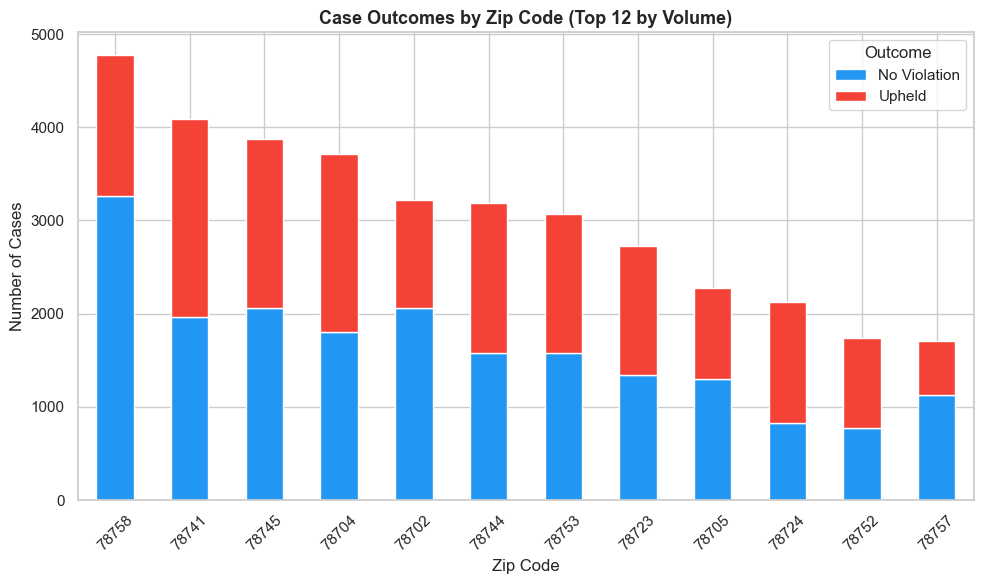

In [19]:
# Outcome by top zip codes
zip_outcome = (
    df_model
    .groupby(['zip_code', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
zip_outcome.columns = ['No Violation', 'Upheld']
zip_outcome['total'] = zip_outcome.sum(axis=1)
top_zips = zip_outcome.nlargest(12, 'total')

fig, ax = plt.subplots(figsize=(10, 6))
top_zips[['No Violation', 'Upheld']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2196F3', '#F44336']
)
ax.set_title('Case Outcomes by Zip Code (Top 12 by Volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Zip Code')
ax.set_ylabel('Number of Cases')
ax.legend(title='Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

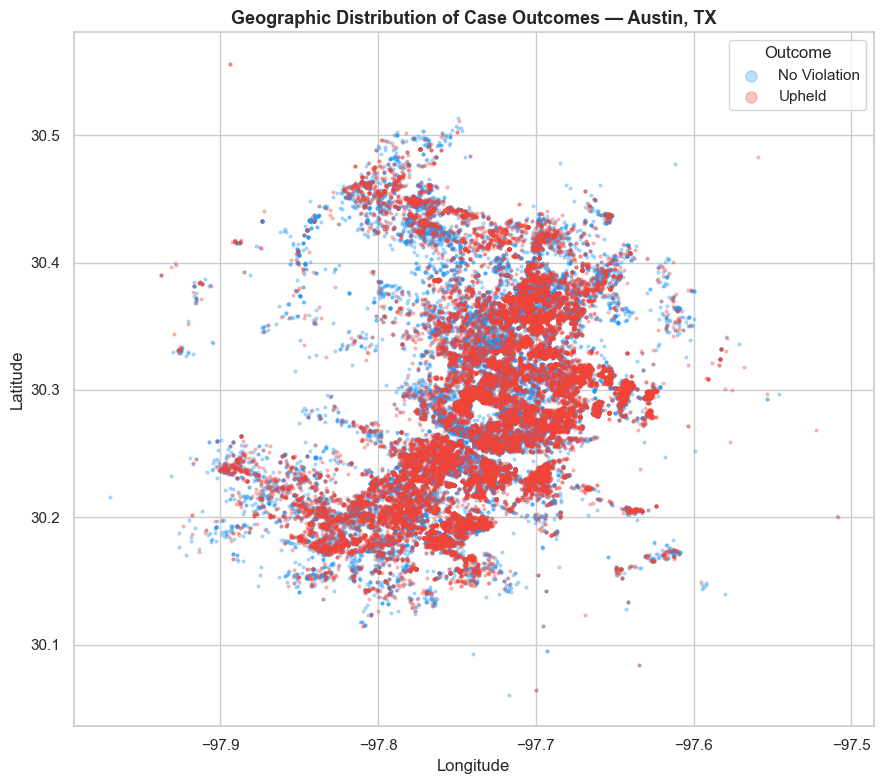

In [20]:
# Geographic scatter plot
geo = df_model.copy()
geo['latitude'] = pd.to_numeric(geo['latitude'], errors='coerce')
geo['longitude'] = pd.to_numeric(geo['longitude'], errors='coerce')
geo = geo.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(9, 8))
for outcome, color, label in [(0, '#2196F3', 'No Violation'), (1, '#F44336', 'Upheld')]:
    grp = geo[geo['violation_upheld'] == outcome]
    ax.scatter(grp['longitude'], grp['latitude'],
               c=color, label=label, alpha=0.3, s=4)

ax.set_title('Geographic Distribution of Case Outcomes — Austin, TX',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Outcome', markerscale=4, fontsize=11)
plt.tight_layout()
plt.show()

## 7. Outlier Analysis

We use the IQR method to detect and handle outliers in numeric features. The key engineered feature `days_to_close` is especially prone to extreme values from long-pending or mis-dated cases.

In [21]:
dtc = df_model['days_to_close'].dropna()

Q1 = dtc.quantile(0.25)
Q3 = dtc.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dtc[(dtc < lower_bound) | (dtc > upper_bound)]
print(f'Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')
print(f'Outlier bounds: [{lower_bound:.1f}, {upper_bound:.1f}]')
print(f'Outlier count: {len(outliers):,} ({len(outliers)/len(dtc)*100:.1f}% of cases)')
print(f'Max days to close: {dtc.max()}')

Q1=1.0  Q3=26.0  IQR=25.0
Outlier bounds: [-36.5, 63.5]
Outlier count: 6,650 (11.0% of cases)
Max days to close: 1009.0


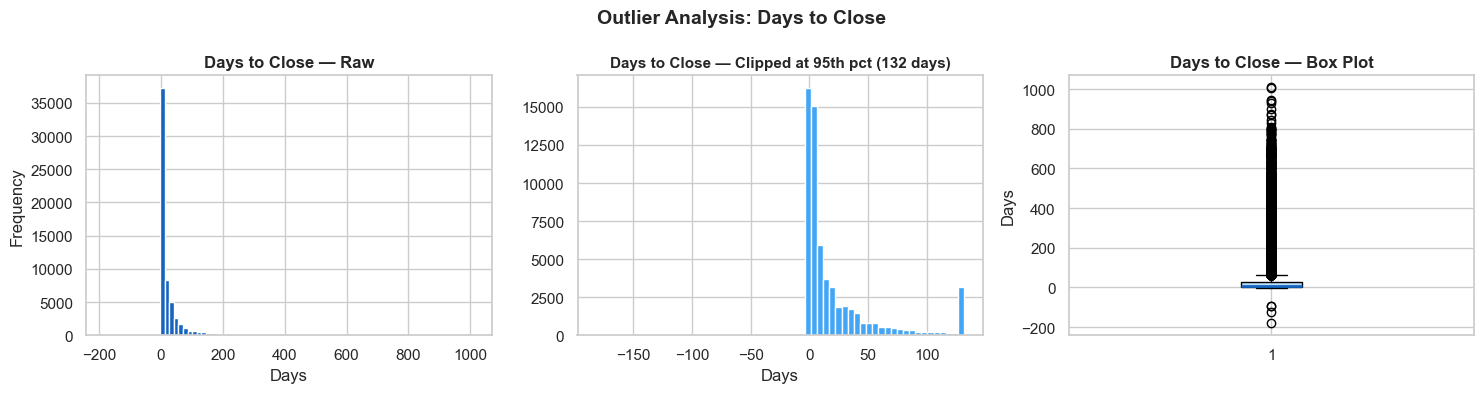

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
axes[0].hist(dtc, bins=80, color='#1565C0', edgecolor='white')
axes[0].set_title('Days to Close — Raw', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')

# Clipped at 95th percentile for readability
clip_val = dtc.quantile(0.95)
axes[1].hist(dtc.clip(upper=clip_val), bins=60, color='#42A5F5', edgecolor='white')
axes[1].set_title(f'Days to Close — Clipped at 95th pct ({clip_val:.0f} days)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Days')

# Box plot
axes[2].boxplot(dtc, patch_artist=True,
                boxprops={'facecolor': '#BBDEFB'},
                medianprops={'color': '#1565C0', 'linewidth': 2})
axes[2].set_title('Days to Close — Box Plot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Days')

plt.suptitle('Outlier Analysis: Days to Close', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cap outliers at IQR upper bound for modeling
df_model['days_to_close_capped'] = df_model['days_to_close'].clip(
    lower=max(0, lower_bound), upper=upper_bound
)

## 8. Text Feature Analysis (NLP)

The `description` field contains standardized complaint type text. We apply TF-IDF vectorization to surface the most informative terms and bigrams across the complaint corpus — and later use these features in the classifier.

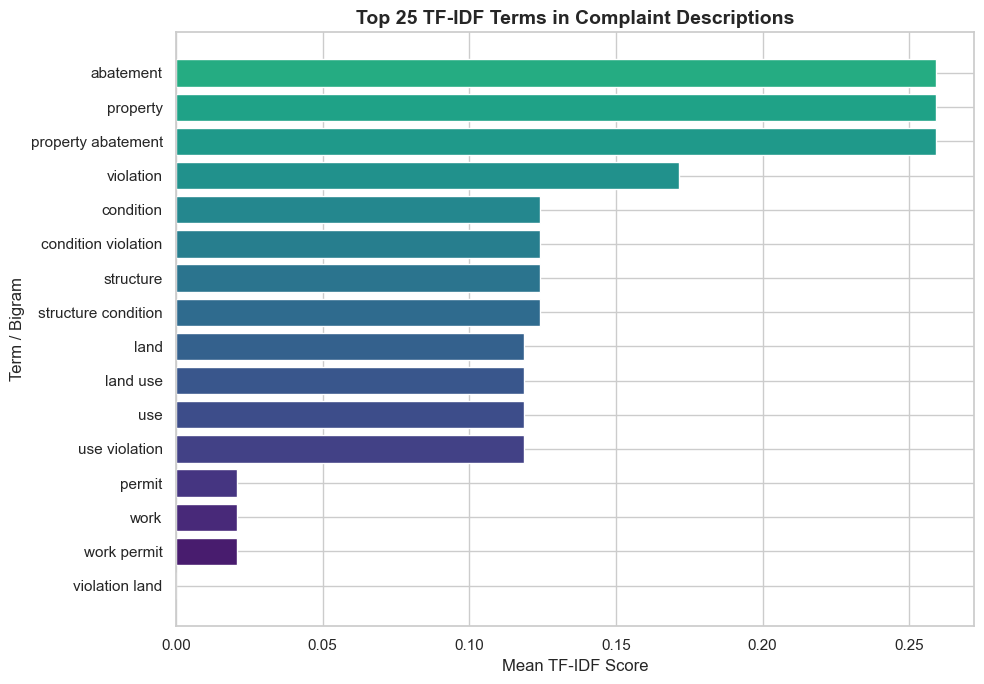

In [23]:
tfidf_explore = TfidfVectorizer(max_features=25, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf_explore.fit_transform(df_model['description'].fillna(''))

mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
tfidf_df = pd.DataFrame({
    'term': tfidf_explore.get_feature_names_out(),
    'mean_tfidf': mean_scores
}).sort_values('mean_tfidf', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    tfidf_df['term'][::-1], tfidf_df['mean_tfidf'][::-1],
    color=sns.color_palette('viridis', 25)
)
ax.set_title('Top 25 TF-IDF Terms in Complaint Descriptions',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
ax.set_ylabel('Term / Bigram')
plt.tight_layout()
plt.show()

In [24]:
# Term frequency split by outcome
for label, name in [(0, 'No Violation'), (1, 'Violation Upheld')]:
    subset = df_model[df_model['violation_upheld'] == label]['description'].fillna('')
    top_terms = (
        pd.Series(' '.join(subset).lower().split())
          .value_counts()
          .head(10)
    )
    print(f'\n--- Top terms: {name} ---')
    print(top_terms.to_string())


--- Top terms: No Violation ---
violation(s)    18431
property        13600
abatement       13600
structure        9223
condition        9223
land             9208
use              9208
work             1529
without          1529
permit           1529

--- Top terms: Violation Upheld ---
property        13629
abatement       13629
violation(s)    12830
structure        6781
condition        6781
land             6049
use              6049
work              655
without           655
permit            655


## 9. Baseline Model — Logistic Regression

### Rationale

**Model choice:** Logistic Regression is the appropriate baseline because:
- It produces probability scores (risk scores) directly usable in a risk-scoring dashboard
- Its coefficients are interpretable, letting enforcement officers understand what drives predictions
- It establishes a minimum performance floor for comparison in Module 24 against SVM, Random Forest, and Gradient Boosting

**Evaluation metric — F1-Score (primary):**  
F1 is chosen because class imbalance is possible (more "no violation" cases than upheld), and both types of error carry meaningful costs:
- **False negative**: Missing a real violation — enforcement fails
- **False positive**: Dispatching an inspector for nothing — wastes resources  

F1 balances precision and recall, making it the right metric for this prioritization use case.  
We also report **ROC-AUC** as a secondary measure of overall discriminative power.

In [25]:
# Select modeling features
NUM_FEATURES = [
    'priority', 'opened_month', 'opened_dayofweek', 'opened_year',
    'days_to_close_capped', 'is_repeat_offender', 'is_short_term_rental'
]

df_clean = df_model[NUM_FEATURES + ['description', 'violation_upheld']].copy()
df_clean = df_clean.dropna(subset=['priority', 'days_to_close_capped'])
df_clean['priority'] = df_clean['priority'].astype(int)

X_num = df_clean[NUM_FEATURES].values
y = df_clean['violation_upheld'].astype(int).values

# TF-IDF on description text (100 features)
tfidf_model = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1, 2))
X_text = tfidf_model.fit_transform(df_clean['description']).toarray()

# Combine numeric and text features
X = np.hstack([X_num, X_text])

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution: {pd.Series(y).value_counts().to_dict()}')

Feature matrix shape: (59018, 23)
Target distribution: {0: 33035, 1: 25983}


In [26]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')

# Train logistic regression with balanced class weights to handle imbalance
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print('\n--- Evaluation Metrics ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['No Violation', 'Upheld']))

Train size: 47,214  |  Test size: 11,804



--- Evaluation Metrics ---
Accuracy:  0.7891
F1-Score:  0.7366
ROC-AUC:   0.8343

--- Classification Report ---
              precision    recall  f1-score   support

No Violation       0.77      0.88      0.82      6607
      Upheld       0.82      0.67      0.74      5197

    accuracy                           0.79     11804
   macro avg       0.80      0.78      0.78     11804
weighted avg       0.79      0.79      0.79     11804



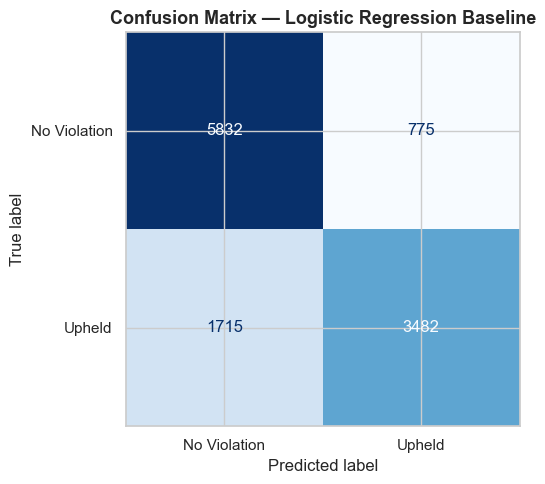

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Violation', 'Upheld'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

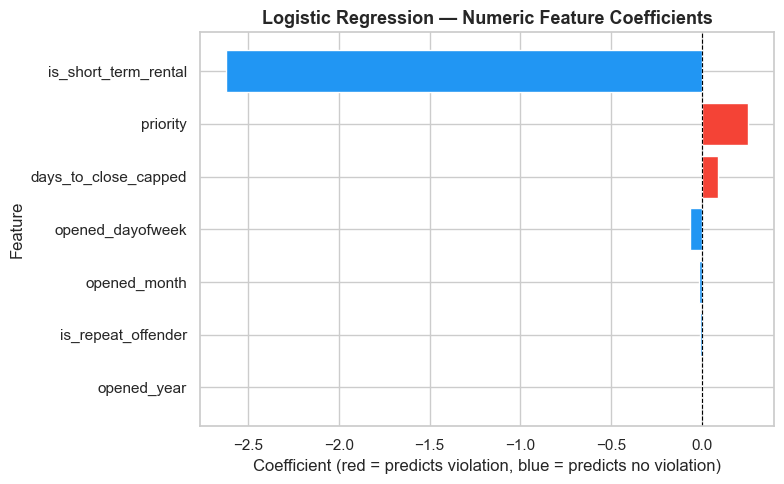

In [28]:
# Numeric feature importance from LR coefficients
coef_df = pd.DataFrame({
    'feature': NUM_FEATURES,
    'coefficient': lr.coef_[0][:len(NUM_FEATURES)]
}).sort_values('coefficient', key=abs, ascending=False)

colors = ['#F44336' if v > 0 else '#2196F3' for v in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
        color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Numeric Feature Coefficients',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (red = predicts violation, blue = predicts no violation)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 10. Summary of Findings

### EDA Highlights

- **Most common complaint type:** Property Abatement (36,334 cases), followed by Structure Condition Violations and Land Use Violations
- **Highest violation rate:** Property Abatement at 50.1%, Structure Condition at 42.4%, Land Use at 39.7%
- **Geographic hotspots:** ZIP codes 78758, 78741, 78745, 78704, and 78702 have the highest complaint volumes
- **Temporal patterns:** Complaints spike Monday–Wednesday and drop sharply on weekends — enforcement is business-hours driven
- **Repeat offenders:** 58.9% violation rate vs 43.5% for first-time complaints — a meaningful predictive signal

### Data Quality
- No duplicate records found
- Missing values: primarily in `closed_date` (open cases), `violationcasenumber` (no formal case), and location fields (~small %)
- Outlier treatment: `days_to_close` capped at IQR upper bound before modeling

### Target Variable
60,672 cases with a defined outcome: **55.3% No Violation, 44.7% Violation Upheld** — well-balanced for binary classification.

### Baseline Model Performance — Logistic Regression

| Metric | Score |
|---|---|
| Accuracy | 78.9% |
| F1-Score | 0.737 |
| ROC-AUC | 0.834 |

**Interpretation:** A ROC-AUC of 0.834 means the model correctly ranks a random violation case above a random non-violation case 83% of the time — strong discriminative ability for a baseline. F1 of 0.737 reflects good balance between precision and recall across both classes.

### Next Steps (Module 24)
1. Tune hyperparameters via cross-validation
2. Implement and compare SVM (RBF kernel), Random Forest, and Gradient Boosting
3. Apply PCA to the TF-IDF feature space for dimensionality reduction
4. Build a risk-scoring output for non-technical enforcement staff